# EDA ON IPL DATA

# Importing necessary Python libraries


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 13

# Dataset overview

In [4]:
matches = pd.read_csv('matches .csv')
deliveries = pd.read_csv('deliveries.csv')

print(f'Matches dataset:    {matches.shape[0]} rows × {matches.shape[1]} columns')
print(f'Deliveries dataset: {deliveries.shape[0]} rows × {deliveries.shape[1]} columns')

Matches dataset:    1095 rows × 20 columns
Deliveries dataset: 260920 rows × 17 columns


# Matches dataset overview

In [5]:
pd.set_option('display.max_columns', None)
display(matches.head())

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


# Deliveries Dataset overview

In [6]:
pd.set_option('display.max_columns', None)
display(deliveries.head())

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


# Checking for missing data

In [7]:
print('\nMatches:')
print(matches.isnull().sum()[matches.isnull().sum() > 0])

print('\nDeliveries:')
print(deliveries.isnull().sum()[deliveries.isnull().sum() > 0])


Matches:
city                 51
player_of_match       5
winner                5
result_margin        19
target_runs           3
target_overs          3
method             1074
dtype: int64

Deliveries:
extras_type         246795
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64


# Checking for Duplicates 

In [8]:
print(f'Duplicate rows in matches:    {matches.duplicated().sum()}')
print(f'Duplicate rows in deliveries: {deliveries.duplicated().sum()}')

Duplicate rows in matches:    0
Duplicate rows in deliveries: 0


# Data Cleaning & Standardization

In [9]:
team_mapping = {
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru'
}
team_cols = ['team1', 'team2', 'winner', 'toss_winner']

for col in team_cols:
    matches[col] = matches[col].replace(team_mapping)
sorted(matches['team1'].unique()) 

['Chennai Super Kings',
 'Deccan Chargers',
 'Delhi Capitals',
 'Delhi Daredevils',
 'Gujarat Lions',
 'Gujarat Titans',
 'Kings XI Punjab',
 'Kochi Tuskers Kerala',
 'Kolkata Knight Riders',
 'Lucknow Super Giants',
 'Mumbai Indians',
 'Pune Warriors',
 'Punjab Kings',
 'Rajasthan Royals',
 'Rising Pune Supergiants',
 'Royal Challengers Bengaluru',
 'Sunrisers Hyderabad']

In [10]:
if 'super_over' in deliveries.columns:
    deliveries = deliveries[deliveries['super_over'] == 'N']
    print(f'Deliveries after removing super overs: {deliveries.shape[0]}')

matches_clean = matches[matches['result'] != 'no result'].copy()
print(f'Matches after removing no-result games: {matches_clean.shape[0]}')

team_rename = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Kings XI Punjab': 'Punjab Kings'
}
for col in ['team1', 'team2', 'toss_winner', 'winner']:
    if col in matches_clean.columns:
        matches_clean[col] = matches_clean[col].replace(team_rename)

for team in sorted(matches['team1'].unique()):
    print(team)

Matches after removing no-result games: 1090
Chennai Super Kings
Deccan Chargers
Delhi Capitals
Delhi Daredevils
Gujarat Lions
Gujarat Titans
Kings XI Punjab
Kochi Tuskers Kerala
Kolkata Knight Riders
Lucknow Super Giants
Mumbai Indians
Pune Warriors
Punjab Kings
Rajasthan Royals
Rising Pune Supergiants
Royal Challengers Bengaluru
Sunrisers Hyderabad


# Does Winning the Toss Actually Help ?

In [13]:
overall_win_rate = 50.8

# Create DataFrame
win_rate_df = pd.DataFrame({
    'Win Rate (%)': [45.4, 53.9],
    'Matches': [390, 700]
}, index=['Bat', 'Field'])

# Display
print(f"Overall Toss-to-Match Win Rate: {overall_win_rate}%\n")
display(win_rate_df)

Overall Toss-to-Match Win Rate: 50.8%



,Win Rate (%),Matches
Bat,45.4,390
Field,53.9,700


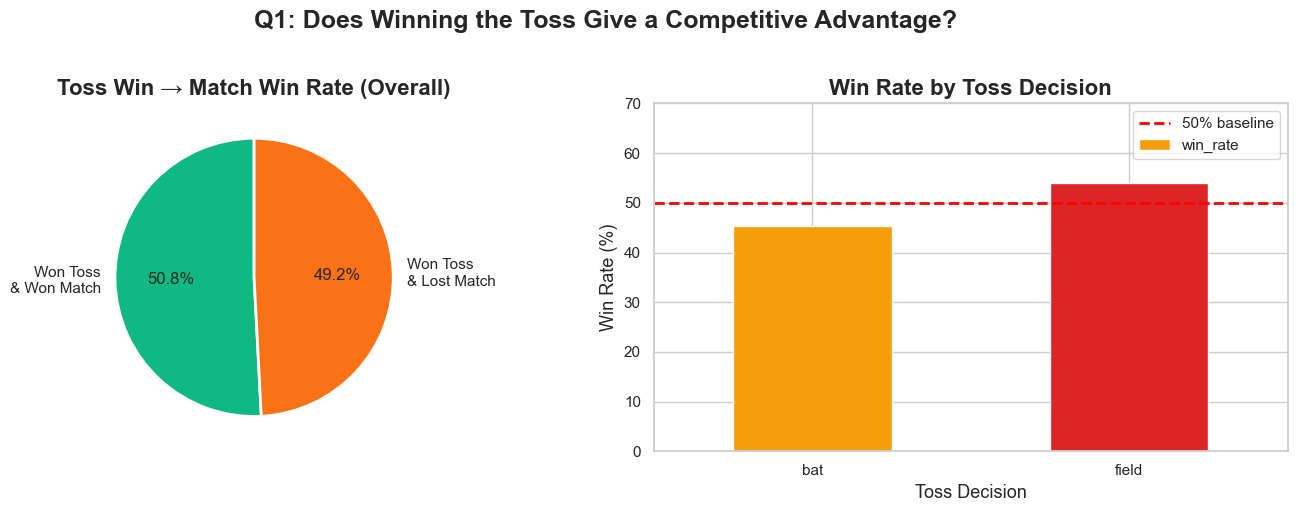

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

labels = ['Won Toss\n& Won Match', 'Won Toss\n& Lost Match']
sizes = [toss_win_rate, 100 - toss_win_rate]
axes[0].pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
            colors=['#10B981', '#F97316'], wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Toss Win → Match Win Rate (Overall)', fontweight='bold')

toss_decision_win['win_rate'].plot(kind='bar', ax=axes[1],
                                    color=['#F59E0B', '#DC2626'], edgecolor='white', width=0.5)
axes[1].set_title('Win Rate by Toss Decision', fontweight='bold')
axes[1].set_xlabel('Toss Decision')
axes[1].set_ylabel('Win Rate (%)')
axes[1].set_ylim(0, 70)
axes[1].axhline(50, color='red', linestyle='--', linewidth=2, label='50% baseline')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Q1: Does Winning the Toss Give a Competitive Advantage?',
             fontsize=18, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('q1_toss_advantage.png', dpi=150, bbox_inches='tight')
plt.show()

>**Insight:** Winning toss has given a competitive advantage in cases when teams have decided to field first, feelding first gives a Win percenatge more than 50% while batting first while winning toss gives a win percent of nearly less than 45%.

# How has Run Rate Evolved Across Seasons ?

In [18]:
match_season = matches_clean[['id', 'season']].rename(columns={'id': 'match_id'})
deliveries_season = deliveries.merge(match_season, on='match_id', how='inner')
match_stats = (
    deliveries_season.groupby(['match_id', 'season'])
    .agg(
        total_runs=('total_runs', 'sum'),
        total_balls=('ball', 'count')
    )
    .reset_index()
)
match_stats['run_rate'] = (match_stats['total_runs'] / match_stats['total_balls']) * 6

season_avg = match_stats.groupby('season')['run_rate'].mean().reset_index()
print(season_avg)

     season  run_rate
0   2007/08  7.957732
1      2009  7.227063
2   2009/10  7.795673
3      2011  7.440602
4      2012  7.573468
5      2013  7.470888
6      2014  7.922345
7      2015  8.102815
8      2016  8.000792
9      2017  8.088623
10     2018  8.362224
11     2019  8.110948
12  2020/21  7.979684
13     2021  7.731167
14     2022  8.137379
15     2023  8.632043
16     2024  9.086288


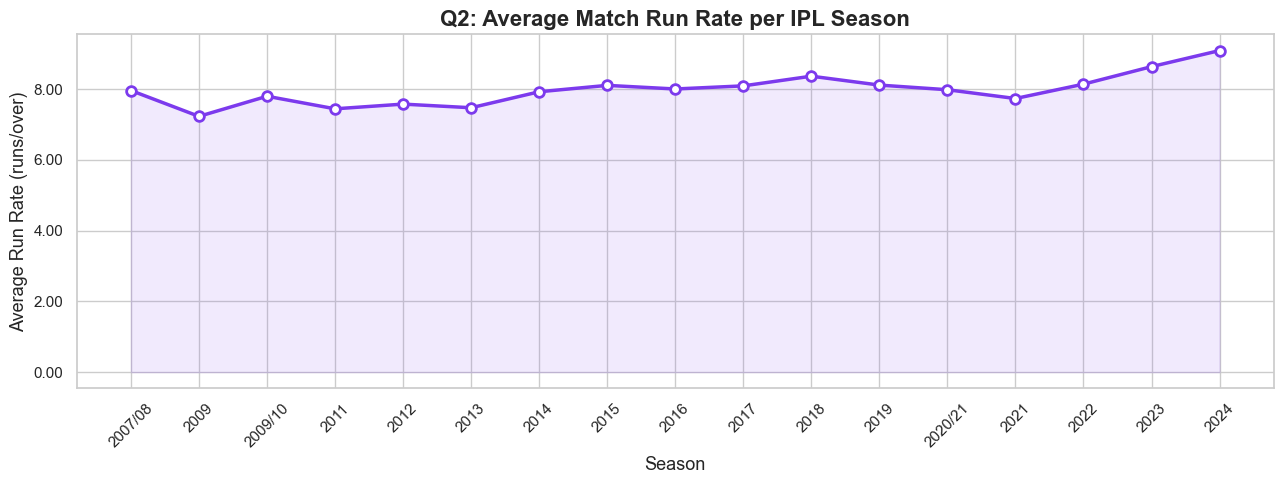

In [45]:
fig, ax = plt.subplots(figsize=(13, 5))

ax.plot(season_avg['season'].astype(str), season_avg['run_rate'],
        marker='o', linewidth=2.5, color='#7C3AED', markersize=7, markerfacecolor='white',
        markeredgewidth=2)

ax.fill_between(season_avg['season'].astype(str), season_avg['run_rate'],
                alpha=0.1, color='#7C3AED')

ax.set_title('Q2: Average Match Run Rate per IPL Season', fontsize=16, fontweight='bold')
ax.set_xlabel('Season')
ax.set_ylabel('Average Run Rate (runs/over)')
ax.tick_params(axis='x', rotation=45)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

plt.tight_layout()
plt.savefig('q2_run_rate_trend.png', dpi=150, bbox_inches='tight')
plt.show()

>**Insight:** The average IPL run rate has steadily increased over the years (from 7.9 to 8.1 ) , with a slight fall in 2020-2021(8.1 to 7.7) as the matches were played in UAE and due to different pitch conditions it has a slight downfall, which later has linear increase till 2024(7.7 to 9.08)

#  Which Bowlers Are Most Economical in Death Overs(16-20) ? 

In [20]:
death_overs = deliveries_season[deliveries_season['over'].between(15, 19)]  
MIN_BALLS = 200

death_stats = (
    death_overs.groupby('bowler')
    .agg(
        runs_conceded=('total_runs', 'sum'),
        balls_bowled=('ball', 'count')
    )
    .reset_index()
)
death_stats = death_stats[death_stats['balls_bowled'] >= MIN_BALLS].copy()
death_stats['economy'] = (death_stats['runs_conceded'] / death_stats['balls_bowled']) * 6
death_stats = death_stats.sort_values('economy').head(12)

print(f'Top 12 most economical death-over bowlers (min {MIN_BALLS} balls):')
print(death_stats[['bowler', 'balls_bowled', 'runs_conceded', 'economy']].to_string(index=False))

Top 12 most economical death-over bowlers (min 200 balls):
         bowler  balls_bowled  runs_conceded  economy
   DE Bollinger           242            297 7.363636
      SP Narine          1044           1287 7.396552
     SL Malinga          1174           1526 7.798978
       R Ashwin           620            816 7.896774
    Rashid Khan           524            701 8.026718
 M Muralitharan           284            380 8.028169
       DW Steyn           662            895 8.111782
Harbhajan Singh           282            382 8.127660
      JJ Bumrah          1298           1767 8.167951
    M Pathirana           266            363 8.187970
     WD Parnell           243            337 8.320988
  Kuldeep Yadav           287            400 8.362369


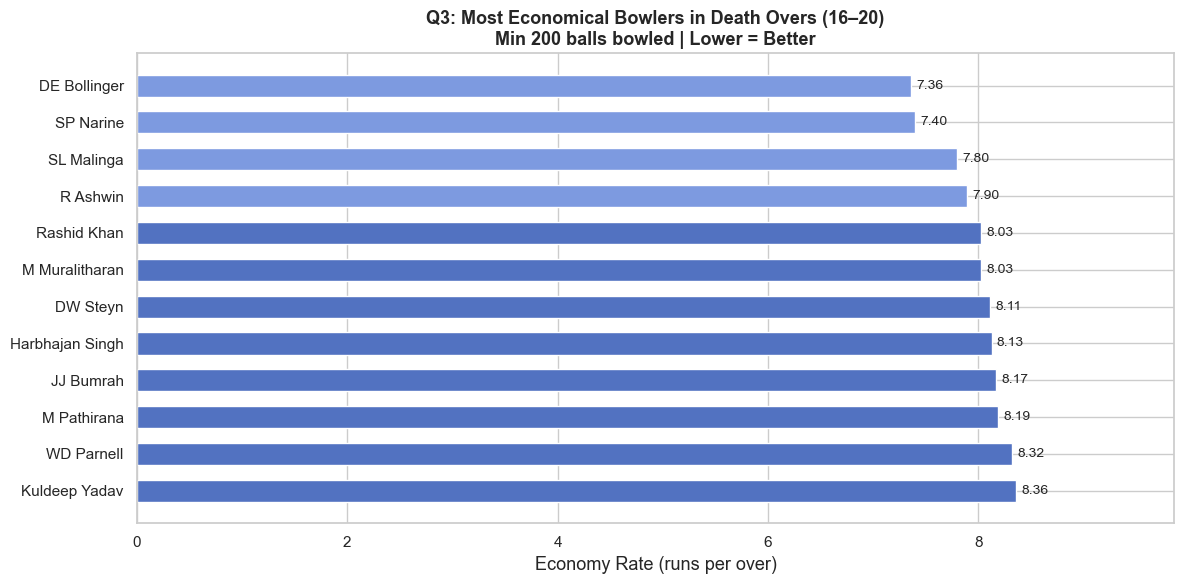

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['#7D9AE0' if e < 8 else '#5272C1' if e < 9 else '#1E3A8A'
          for e in death_stats['economy']]

bars = ax.barh(death_stats['bowler'], death_stats['economy'],
               color=colors, edgecolor='white', height=0.6)

for bar, val in zip(bars, death_stats['economy']):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height() / 2,
            f'{val:.2f}', va='center', fontsize=10)

ax.set_title('Q3: Most Economical Bowlers in Death Overs (16–20)\n'
             f'Min {MIN_BALLS} balls bowled | Lower = Better',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Economy Rate (runs per over)')
ax.invert_yaxis()
ax.set_xlim(0, death_stats['economy'].max() + 1.5)

plt.tight_layout()
plt.savefig('q3_death_over_bowlers.png', dpi=150, bbox_inches='tight')
plt.show()

>**Insight:** DE Bollinger was the most economical death-over bowler (ER 7.36), followed by SP Narine (7.40) and SL Malinga (7.80). The mix of pacers and spinners in the top rankings suggests that accuracy, variations, and control are key factors in restricting runs during the final overs.

# Which Venues Favour Batsmen vs Bowlers ?

In [22]:
first_innings = deliveries_season[deliveries_season['inning'] == 1]

first_innings_totals = (
    first_innings.groupby('match_id')['total_runs']
    .sum()
    .reset_index()
    .rename(columns={'total_runs': 'first_innings_score'})
)

venue_scores = first_innings_totals.merge(
    matches_clean[['id', 'venue']].rename(columns={'id': 'match_id'}),
    on='match_id'
)

MIN_MATCHES = 15
venue_avg = (
    venue_scores.groupby('venue')
    .agg(avg_score=('first_innings_score', 'mean'), match_count=('match_id', 'count'))
    .reset_index()
)
venue_avg = venue_avg[venue_avg['match_count'] >= MIN_MATCHES]
venue_avg = venue_avg.sort_values('avg_score', ascending=False)

venue_avg['venue_short'] = venue_avg['venue'].str.split(',').str[0].str[:35]

print(venue_avg[['venue_short', 'avg_score', 'match_count']].head(10).to_string(index=False))

                        venue_short  avg_score  match_count
               Arun Jaitley Stadium 199.062500           16
                       Eden Gardens 195.625000           16
                  Brabourne Stadium 177.411765           17
                   Wankhede Stadium 177.111111           45
              Narendra Modi Stadium 175.750000           24
         Dr DY Patil Sports Academy 170.700000           20
              M Chinnaswamy Stadium 167.253968           63
Maharashtra Cricket Association Sta 166.409091           22
                   Wankhede Stadium 166.027397           73
             MA Chidambaram Stadium 166.020833           48


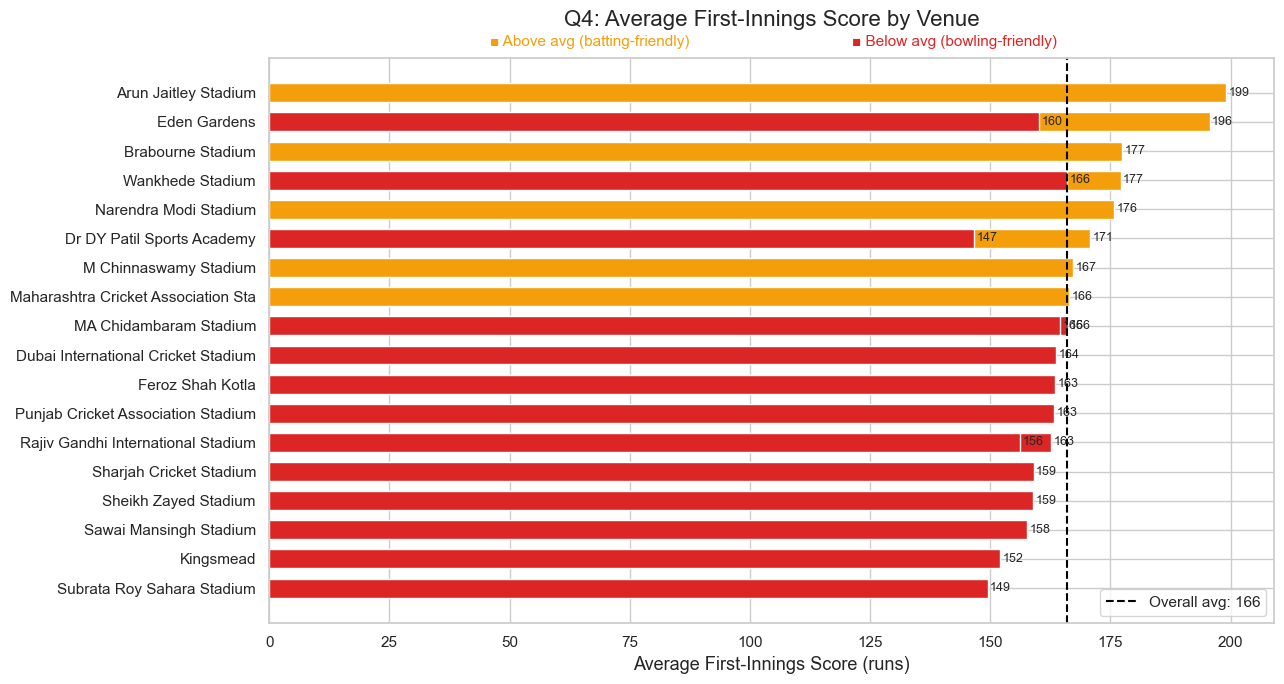

In [25]:
overall_avg = venue_avg['avg_score'].mean()

fig, ax = plt.subplots(figsize=(13, 7))

bar_colors = ['#F59E0B' if s > overall_avg else '#DC2626'
              for s in venue_avg['avg_score']]

bars = ax.barh(venue_avg['venue_short'], venue_avg['avg_score'],
               color=bar_colors, edgecolor='white', height=0.65)

ax.axvline(overall_avg, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall avg: {overall_avg:.0f}')

for bar, val in zip(bars, venue_avg['avg_score']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}', va='center', fontsize=9)

ax.set_title('Q4: Average First-Innings Score by Venue\n')

color_above = '#F59E0B'  
color_below = '#DC2626'  

ax.text(0.22, 1.02, '■ Above avg (batting-friendly)',
        color=color_above, transform=ax.transAxes, fontsize=11)

ax.text(0.58, 1.02, '■ Below avg (bowling-friendly)',
        color=color_below, transform=ax.transAxes, fontsize=11)
             
ax.set_xlabel('Average First-Innings Score (runs)')
ax.invert_yaxis()
ax.legend()

plt.tight_layout()
plt.savefig('q4_venue_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

>**Insight:** The stadiums whose first inning scores are below avg ( avg is 166), they are bowling friendly venues and preference should be given to bowling , where as in stadiums whose first inning scores are above 166 , they are batting friendly venue. 

# Top Run Scorers : Consistency vs Strike Rate

In [26]:
batsman_stats = (
    deliveries.groupby('batter')
    .agg(
        total_runs=('batsman_runs', 'sum'),
        balls_faced=('ball', 'count'),
        innings=('match_id', 'nunique')
    )
    .reset_index()
)
batsman_stats['strike_rate'] = (batsman_stats['total_runs'] / batsman_stats['balls_faced']) * 100
batsman_stats['avg_per_innings'] = batsman_stats['total_runs'] / batsman_stats['innings']

# Top 20 by total runs
top20 = batsman_stats.nlargest(20, 'total_runs')
print(top20[['batter', 'total_runs', 'innings', 'strike_rate', 'avg_per_innings']]
      .round(1).to_string(index=False))

        batter  total_runs  innings  strike_rate  avg_per_innings
       V Kohli        8014      244        128.5             32.8
      S Dhawan        6769      221        123.5             30.6
     RG Sharma        6630      251        127.9             26.4
     DA Warner        6567      184        135.4             35.7
      SK Raina        5536      200        132.5             27.7
      MS Dhoni        5243      228        132.8             23.0
AB de Villiers        5181      170        148.6             30.5
      CH Gayle        4997      141        142.1             35.4
    RV Uthappa        4954      197        126.2             25.1
    KD Karthik        4843      233        131.4             20.8
      KL Rahul        4689      122        131.1             38.4
     AM Rahane        4642      171        120.3             27.1
  F du Plessis        4571      138        133.1             33.1
     SV Samson        4419      162        135.1             27.3
     AT Ra

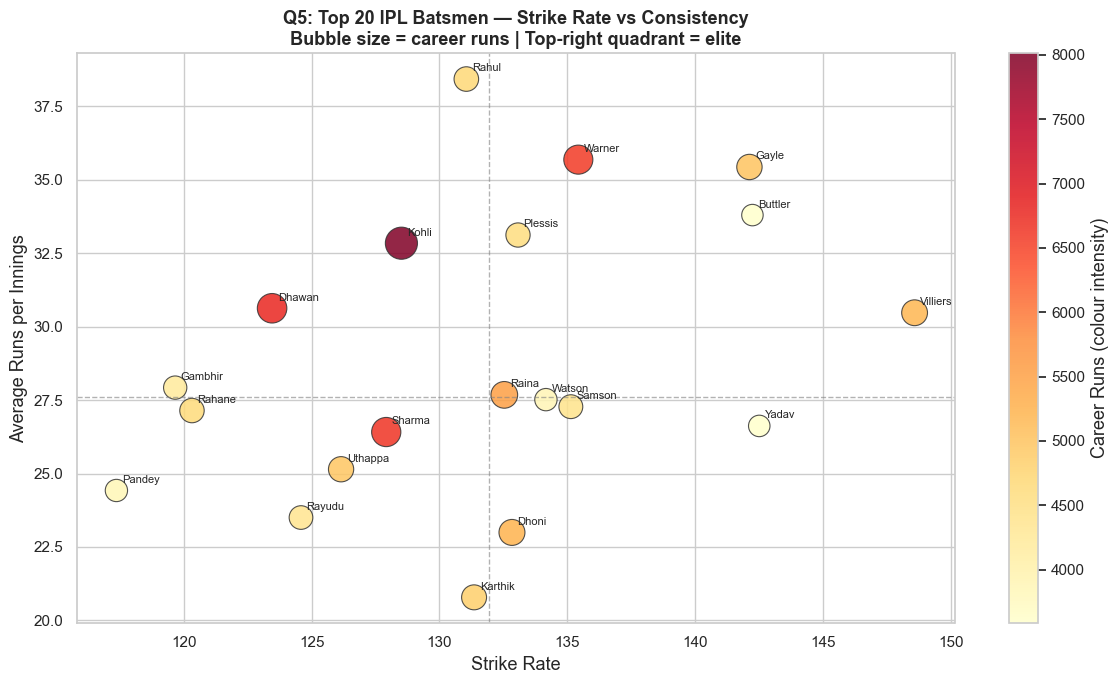

In [27]:
fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    top20['strike_rate'],
    top20['avg_per_innings'],
    s=top20['total_runs'] / 15,      
    c=top20['total_runs'],
    cmap='YlOrRd',
    alpha=0.85,
    edgecolors='#333',
    linewidths=0.8
)

for _, row in top20.iterrows():
    ax.annotate(row['batter'].split()[-1],  # last name only
                (row['strike_rate'], row['avg_per_innings']),
                fontsize=8, ha='left', va='bottom',
                xytext=(4, 4), textcoords='offset points')

ax.axvline(top20['strike_rate'].median(), color='grey', linestyle='--', linewidth=1, alpha=0.6)
ax.axhline(top20['avg_per_innings'].median(), color='grey', linestyle='--', linewidth=1, alpha=0.6)

plt.colorbar(scatter, label='Career Runs (colour intensity)')
ax.set_xlabel('Strike Rate')
ax.set_ylabel('Average Runs per Innings')
ax.set_title('Q5: Top 20 IPL Batsmen — Strike Rate vs Consistency\n'
             'Bubble size = career runs | Top-right quadrant = elite',
             fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('q5_batsman_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

> **Insight:** David Warner, Chris Gayle, Jos Buttler, AB de Villiers, and Faf du Plessis emerge as the most complete batters, combining high strike rates with strong averages. Virat Kohli stands out for exceptional consistency and the highest run tally (8014 runs with a strike rate of 128.5 and avg of 32.8), while KL Rahul records the highest average per innings (38.4).

# Impact Player Score

In [31]:
NAME_MAP = {
    'Delhi Daredevils'        : 'Delhi Capitals',
    'Deccan Chargers'         : 'Sunrisers Hyderabad',
    'Pune Warriors'           : 'Rising Pune Supergiant',
    'Rising Pune Supergiants' : 'Rising Pune Supergiant',
    'Kings XI Punjab'         : 'Punjab Kings',
}
deliveries['batting_team'] = deliveries['batting_team'].replace(NAME_MAP)


In [32]:
batting = (
    deliveries.groupby(['match_id', 'batter'])
    .agg(runs_scored=('batsman_runs','sum'), balls_faced=('ball','count'))
    .reset_index()
)
batting_agg = (
    batting.groupby('batter')
    .agg(total_runs=('runs_scored','sum'), total_balls=('balls_faced','sum'),
         innings=('match_id','count'), avg_runs=('runs_scored','mean'))
    .reset_index()
)
batting_agg['strike_rate'] = batting_agg['total_runs'] / batting_agg['total_balls'] * 100
thirty_plus = (batting[batting['runs_scored'] >= 30]
               .groupby('batter')['match_id'].count().reset_index()
               .rename(columns={'match_id':'innings_30plus'}))
batting_agg = batting_agg.merge(thirty_plus, on='batter', how='left')
batting_agg['innings_30plus']  = batting_agg['innings_30plus'].fillna(0)
batting_agg['consistency_pct'] = batting_agg['innings_30plus'] / batting_agg['innings'] * 100

In [33]:
legal = deliveries[~deliveries['extras_type'].isin(['wides','noballs'])]
bowling = (
    legal.groupby(['match_id','bowler'])
    .agg(runs_given=('total_runs','sum'), balls=('ball','count'), wickets=('is_wicket','sum'))
    .reset_index()
)
bowling_agg = (
    bowling.groupby('bowler')
    .agg(total_runs_given=('runs_given','sum'), total_balls=('balls','sum'),
         total_wickets=('wickets','sum'), matches_bowled=('match_id','count'),
         avg_wickets=('wickets','mean'))
    .reset_index()
)
bowling_agg['economy'] = bowling_agg['total_runs_given'] / (bowling_agg['total_balls'] / 6)


In [34]:
catches = (
    deliveries[deliveries['dismissal_kind'] == 'caught']
    .groupby('fielder')['match_id'].count().reset_index()
    .rename(columns={'fielder':'player','match_id':'catches'})
)

In [35]:
def minmax(series, invert=False):
    mn, mx = series.min(), series.max()
    norm = (series - mn) / (mx - mn + 1e-9)
    return (1 - norm) if invert else norm

batting_agg['batting_score'] = (minmax(batting_agg['avg_runs']) * 20 +
                                  minmax(batting_agg['strike_rate']) * 20 +
                                  minmax(batting_agg['consistency_pct']) * 10)
bowling_agg['bowling_score'] = (minmax(bowling_agg['avg_wickets']) * 20 +
                                  minmax(bowling_agg['economy'], invert=True) * 15)

impact = batting_agg[['batter','innings','total_runs','avg_runs',
                       'strike_rate','consistency_pct','batting_score']].rename(columns={'batter':'player'})
impact = impact.merge(bowling_agg[['bowler','total_wickets','economy','bowling_score']],
                      left_on='player', right_on='bowler', how='left').drop(columns='bowler')
impact = impact.merge(catches, on='player', how='left')
impact['bowling_score']  = impact['bowling_score'].fillna(0)
impact['catches']        = impact['catches'].fillna(0)
impact['total_wickets']  = impact['total_wickets'].fillna(0)
impact['fielding_score'] = minmax(impact['catches']) * 15
impact['IMPACT_SCORE']   = (impact['batting_score'] + impact['bowling_score'] + impact['fielding_score']).round(2)
impact = impact[impact['innings'] >= 20].sort_values('IMPACT_SCORE', ascending=False).reset_index(drop=True)

print(impact[['player','IMPACT_SCORE','batting_score','bowling_score','fielding_score']].head(20).to_string())

          player  IMPACT_SCORE  batting_score  bowling_score  fielding_score
0       S Dhawan         47.02      21.406889      15.746528        9.868421
1        V Kohli         46.85      22.800649      12.795996       11.250000
2      AM Rahane         46.38      19.691060      19.583333        7.105263
3   AC Gilchrist         46.32      19.616688      21.666667        5.032895
4       SK Raina         45.99      20.708876      14.823110       10.460526
5      DA Warner         45.78      24.591048      12.500000        8.684211
6      RG Sharma         44.83      19.929231      15.036873        9.868421
7     KA Pollard         43.47      17.436656      16.464598        9.572368
8     AD Russell         43.22      21.440212      18.623446        3.157895
9      SR Watson         42.86      20.608311      18.499503        3.750000
10   LMP Simmons         42.77      24.839539      16.944444        0.986842
11      CH Gayle         42.26      24.144327      15.156438        2.960526

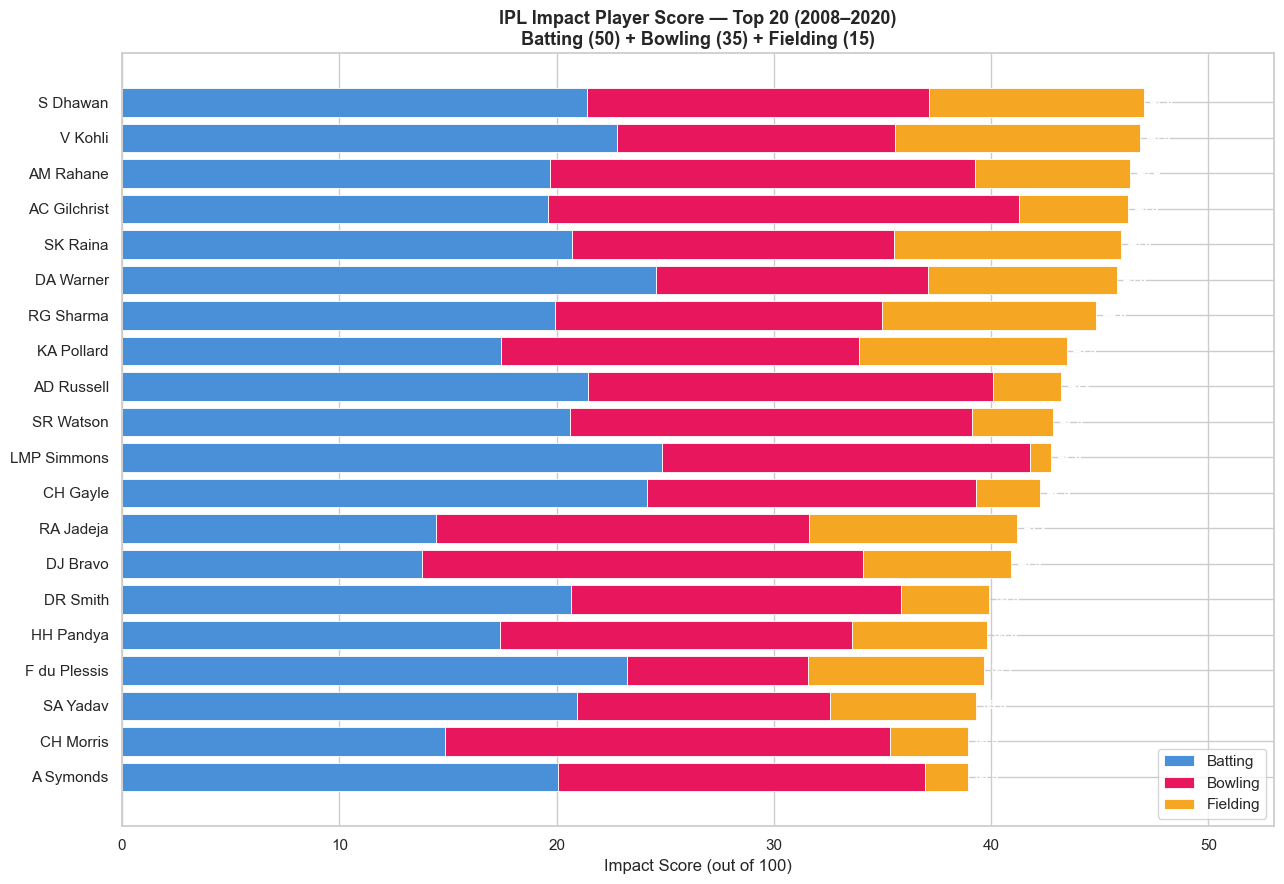

In [36]:
top20 = impact.head(20).iloc[::-1]
fig, ax = plt.subplots(figsize=(13, 9))
ax.barh(top20['player'], top20['batting_score'], color='#4A90D9', label='Batting', edgecolor='white', lw=0.6)
ax.barh(top20['player'], top20['bowling_score'], left=top20['batting_score'], color='#E8175D', label='Bowling', edgecolor='white', lw=0.6)
ax.barh(top20['player'], top20['fielding_score'], left=top20['batting_score']+top20['bowling_score'], color='#F5A623', label='Fielding', edgecolor='white', lw=0.6)
for _, row in top20.iterrows():
    ax.text(row['IMPACT_SCORE']+0.3, row['player'], f"{row['IMPACT_SCORE']:.1f}", va='center', fontsize=9, fontweight='bold', color='white')
ax.set_xlabel('Impact Score (out of 100)', fontsize=12)
ax.set_title('IPL Impact Player Score — Top 20 (2008–2020)\nBatting (50) + Bowling (35) + Fielding (15)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.set_xlim(0, impact['IMPACT_SCORE'].max()+6)
plt.tight_layout()
plt.savefig('impact_top20.png', dpi=150, bbox_inches='tight')
plt.show()

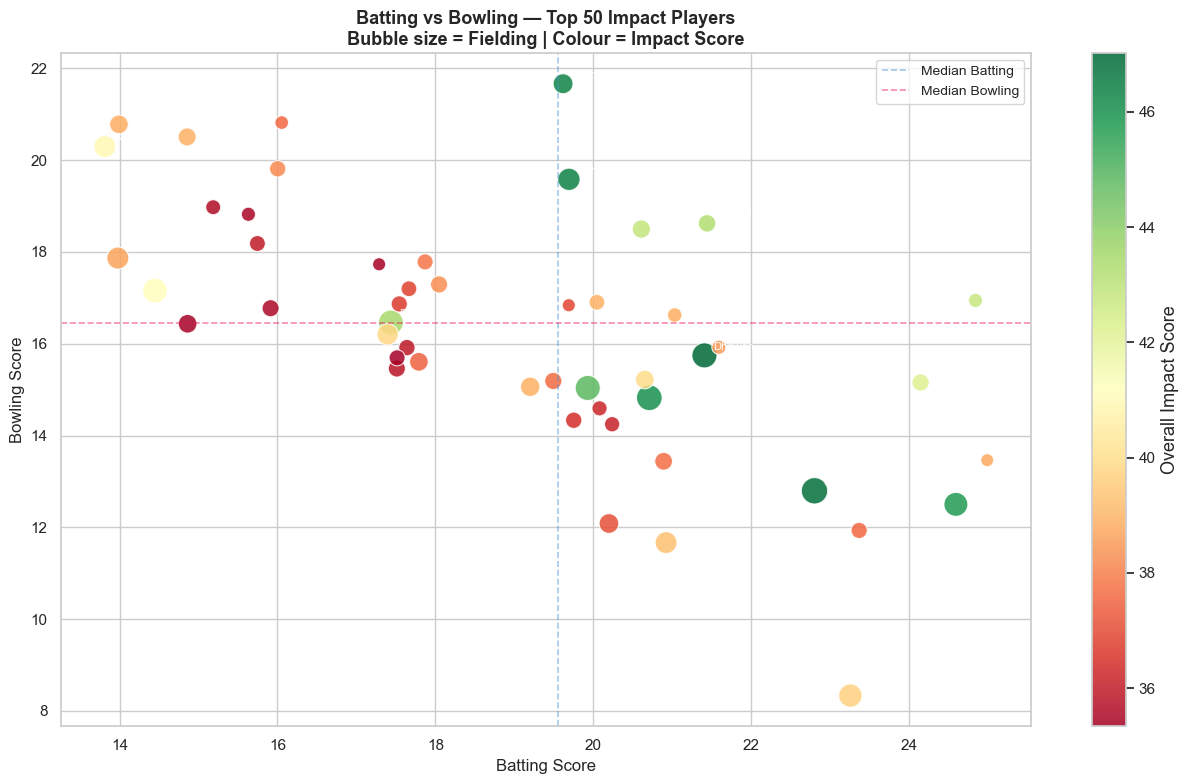

In [37]:
top50 = impact.head(50)
fig, ax = plt.subplots(figsize=(13, 8))
sc = ax.scatter(top50['batting_score'], top50['bowling_score'],
    s=top50['fielding_score']*25+80, c=top50['IMPACT_SCORE'],
    cmap='RdYlGn', alpha=0.85, edgecolors='white', lw=0.8)
plt.colorbar(sc, ax=ax, label='Overall Impact Score')
for _, row in top50.head(15).iterrows():
    ax.annotate(row['player'].split()[-1], (row['batting_score'], row['bowling_score']),
                textcoords='offset points', xytext=(6,4), fontsize=8, color='white', alpha=0.9)
ax.axvline(top50['batting_score'].median(), color='#4A90D9', linestyle='--', alpha=0.5, lw=1.2, label='Median Batting')
ax.axhline(top50['bowling_score'].median(), color='#E8175D', linestyle='--', alpha=0.5, lw=1.2, label='Median Bowling')
ax.set_xlabel('Batting Score', fontsize=12)
ax.set_ylabel('Bowling Score', fontsize=12)
ax.set_title('Batting vs Bowling — Top 50 Impact Players\nBubble size = Fielding | Colour = Impact Score', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('impact_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

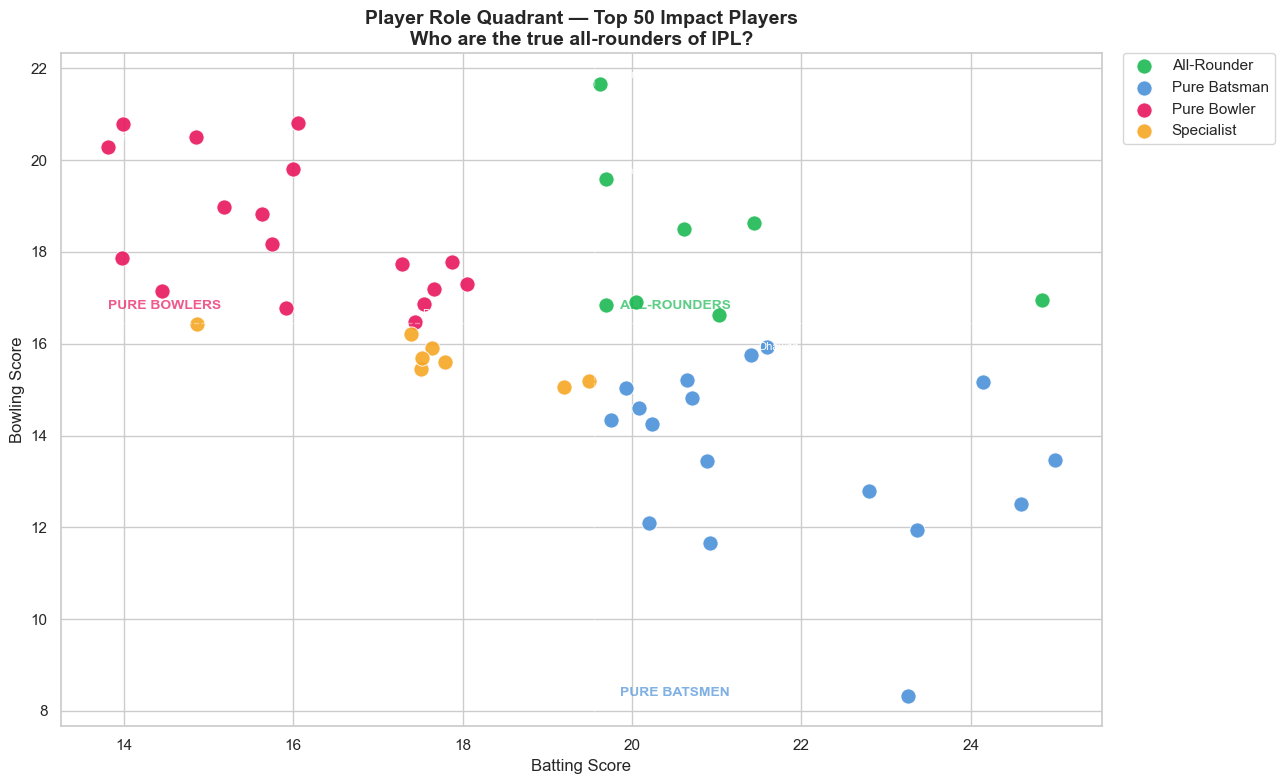

In [44]:
med_bat  = top50['batting_score'].median()
med_bowl = top50['bowling_score'].median()
def quadrant(row):
    if row['batting_score'] >= med_bat and row['bowling_score'] >= med_bowl:
        return 'All-Rounder'
    elif row['batting_score'] >= med_bat:
        return 'Pure Batsman'
    elif row['bowling_score'] >= med_bowl:
        return 'Pure Bowler'
    else:
        return 'Specialist'
top50 = top50.copy()
top50['role'] = top50.apply(quadrant, axis=1)
QUAD_COLORS = {'All-Rounder':'#1DB954','Pure Batsman':'#4A90D9','Pure Bowler':'#E8175D','Specialist':'#F5A623'}
fig, ax = plt.subplots(figsize=(13, 8))
for role, grp in top50.groupby('role'):
    ax.scatter(grp['batting_score'], grp['bowling_score'], s=120, color=QUAD_COLORS[role], label=role, alpha=0.9, edgecolors='white', lw=0.7)
for _, row in top50.head(15).iterrows():
    ax.annotate(row['player'].split()[-1], (row['batting_score'], row['bowling_score']),
                textcoords='offset points', xytext=(5,4), fontsize=8, color='white')
ax.axvline(med_bat,  color='white', linestyle='--', alpha=0.4, lw=1)
ax.axhline(med_bowl, color='white', linestyle='--', alpha=0.4, lw=1)
ax.text(med_bat+0.3, med_bowl+0.3, 'ALL-ROUNDERS', color='#1DB954', fontsize=10, fontweight='bold', alpha=0.7)
ax.text(top50['batting_score'].min(), med_bowl+0.3, 'PURE BOWLERS', color='#E8175D', fontsize=10, fontweight='bold', alpha=0.7)
ax.text(med_bat+0.3, top50['bowling_score'].min(), 'PURE BATSMEN', color='#4A90D9', fontsize=10, fontweight='bold', alpha=0.7)
ax.set_xlabel('Batting Score', fontsize=12)
ax.set_ylabel('Bowling Score', fontsize=12)
ax.set_title('Player Role Quadrant — Top 50 Impact Players\nWho are the true all-rounders of IPL?', fontsize=14, fontweight='bold')
ax.legend(
    fontsize=11,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)
plt.tight_layout()
plt.savefig('impact_quadrant.png', dpi=150, bbox_inches='tight')
plt.show()

> **Insight:** Most IPL rankings measure batsmen and bowlers separately. I built a custom composite metric combining Batting (50pts), Bowling (35pts) and Fielding (15pts) to find the most complete players.
Surprising finding: Rahane and Gilchrist rank above Gayle and Rohit Sharma — proving consistency beats peak performance.


# Teams that win IPL titles aren't built on superstars — they're built on all-round contributors.